# Credit Card Fraud Detection Assessment

Credit card fraud costs people, banks, and businesses billions of dollars every year. In many cases, it may be extremely hard to detect fraud transactions since they may look very similar to legitimate transactions. 

In this assessment, we will train a machine learning model using the Kaggle credit card fraud dataset to learn patterns in past transactions and predict whether or not a transaction is legitimate or fraudulent. We will walk through the full pipeline:

1. **Data Exploration:** Understand the data
2. **Data Preprocessing:** Clean, scale, and split the data appropriately
3. **Customer Segmentation:** Cluster transactions into groups using K-Means clustering

In [1]:
# Install dependencies (Comment this out after running it once)
# !pip install kagglehub imbalanced-learn torch --quiet

Let's download the dataset from Kaggle:

In [2]:
import kagglehub
from pathlib import Path

path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud")) / "creditcard.csv"

if path.exists():
    print("Dataset successfully downloaded")
else:
    print("Dataset not found")

Dataset successfully downloaded


Now let's load the dataset into a Pandas DataFrame so we can further explore:

In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv(path)

print(f"Shape: {df.shape} -> {df.shape[0]} transactions and {df.shape[1]} features\n")

df

Shape: (284807, 31) -> 284807 transactions and 31 features



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


## Dataset Overview

- 284,807 transactions
- V1 - V28 are PCA-transformed features (already scaled and anonymous for privacy)
- Time is in seconds elapsed since the first transaction in the dataset (**needs scaling**)
- Amount is in Euros (**needs scaling**)
- Class: label `0` = legitimate, `1` = fraud

Since V1–V28 are already PCA-transformed, they are already standardized and doesn't need any further scaling. We only need to scale `Time` and `Amount` (after `train_test_split()` to prevent data leakage).

## 1. Data Exploration

Before touching the data, we need to understand it. Some questions we may ask ourselves are:
- Is the data clean? (Ex. Are there any missing values)
- What does the target distribution look like?
- What patterns separate fraudulent from legitimate transactions?

### 1.1 Missing Values

In [4]:
missing_table = df.isnull().sum()                           # Series
print(f"Total missing values: {missing_table.sum()}")

print("\nMissing values by columns:\n")
missing_table = missing_table.reset_index()                 # Reassign Series to a DataFrame
missing_table.columns = ["Column", "Missing Values"]

display(missing_table.style.hide(axis="index"))

Total missing values: 0

Missing values by columns:



Column,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Looks like there are no missing values in the dataset. Let's analyze the distribution further

### 1.2 Feature Distributions & Statistical Summary 

Before deciding how to scale our features, we need to understand the distribution. A histogram can give us a good idea of the distirbution across all the features:

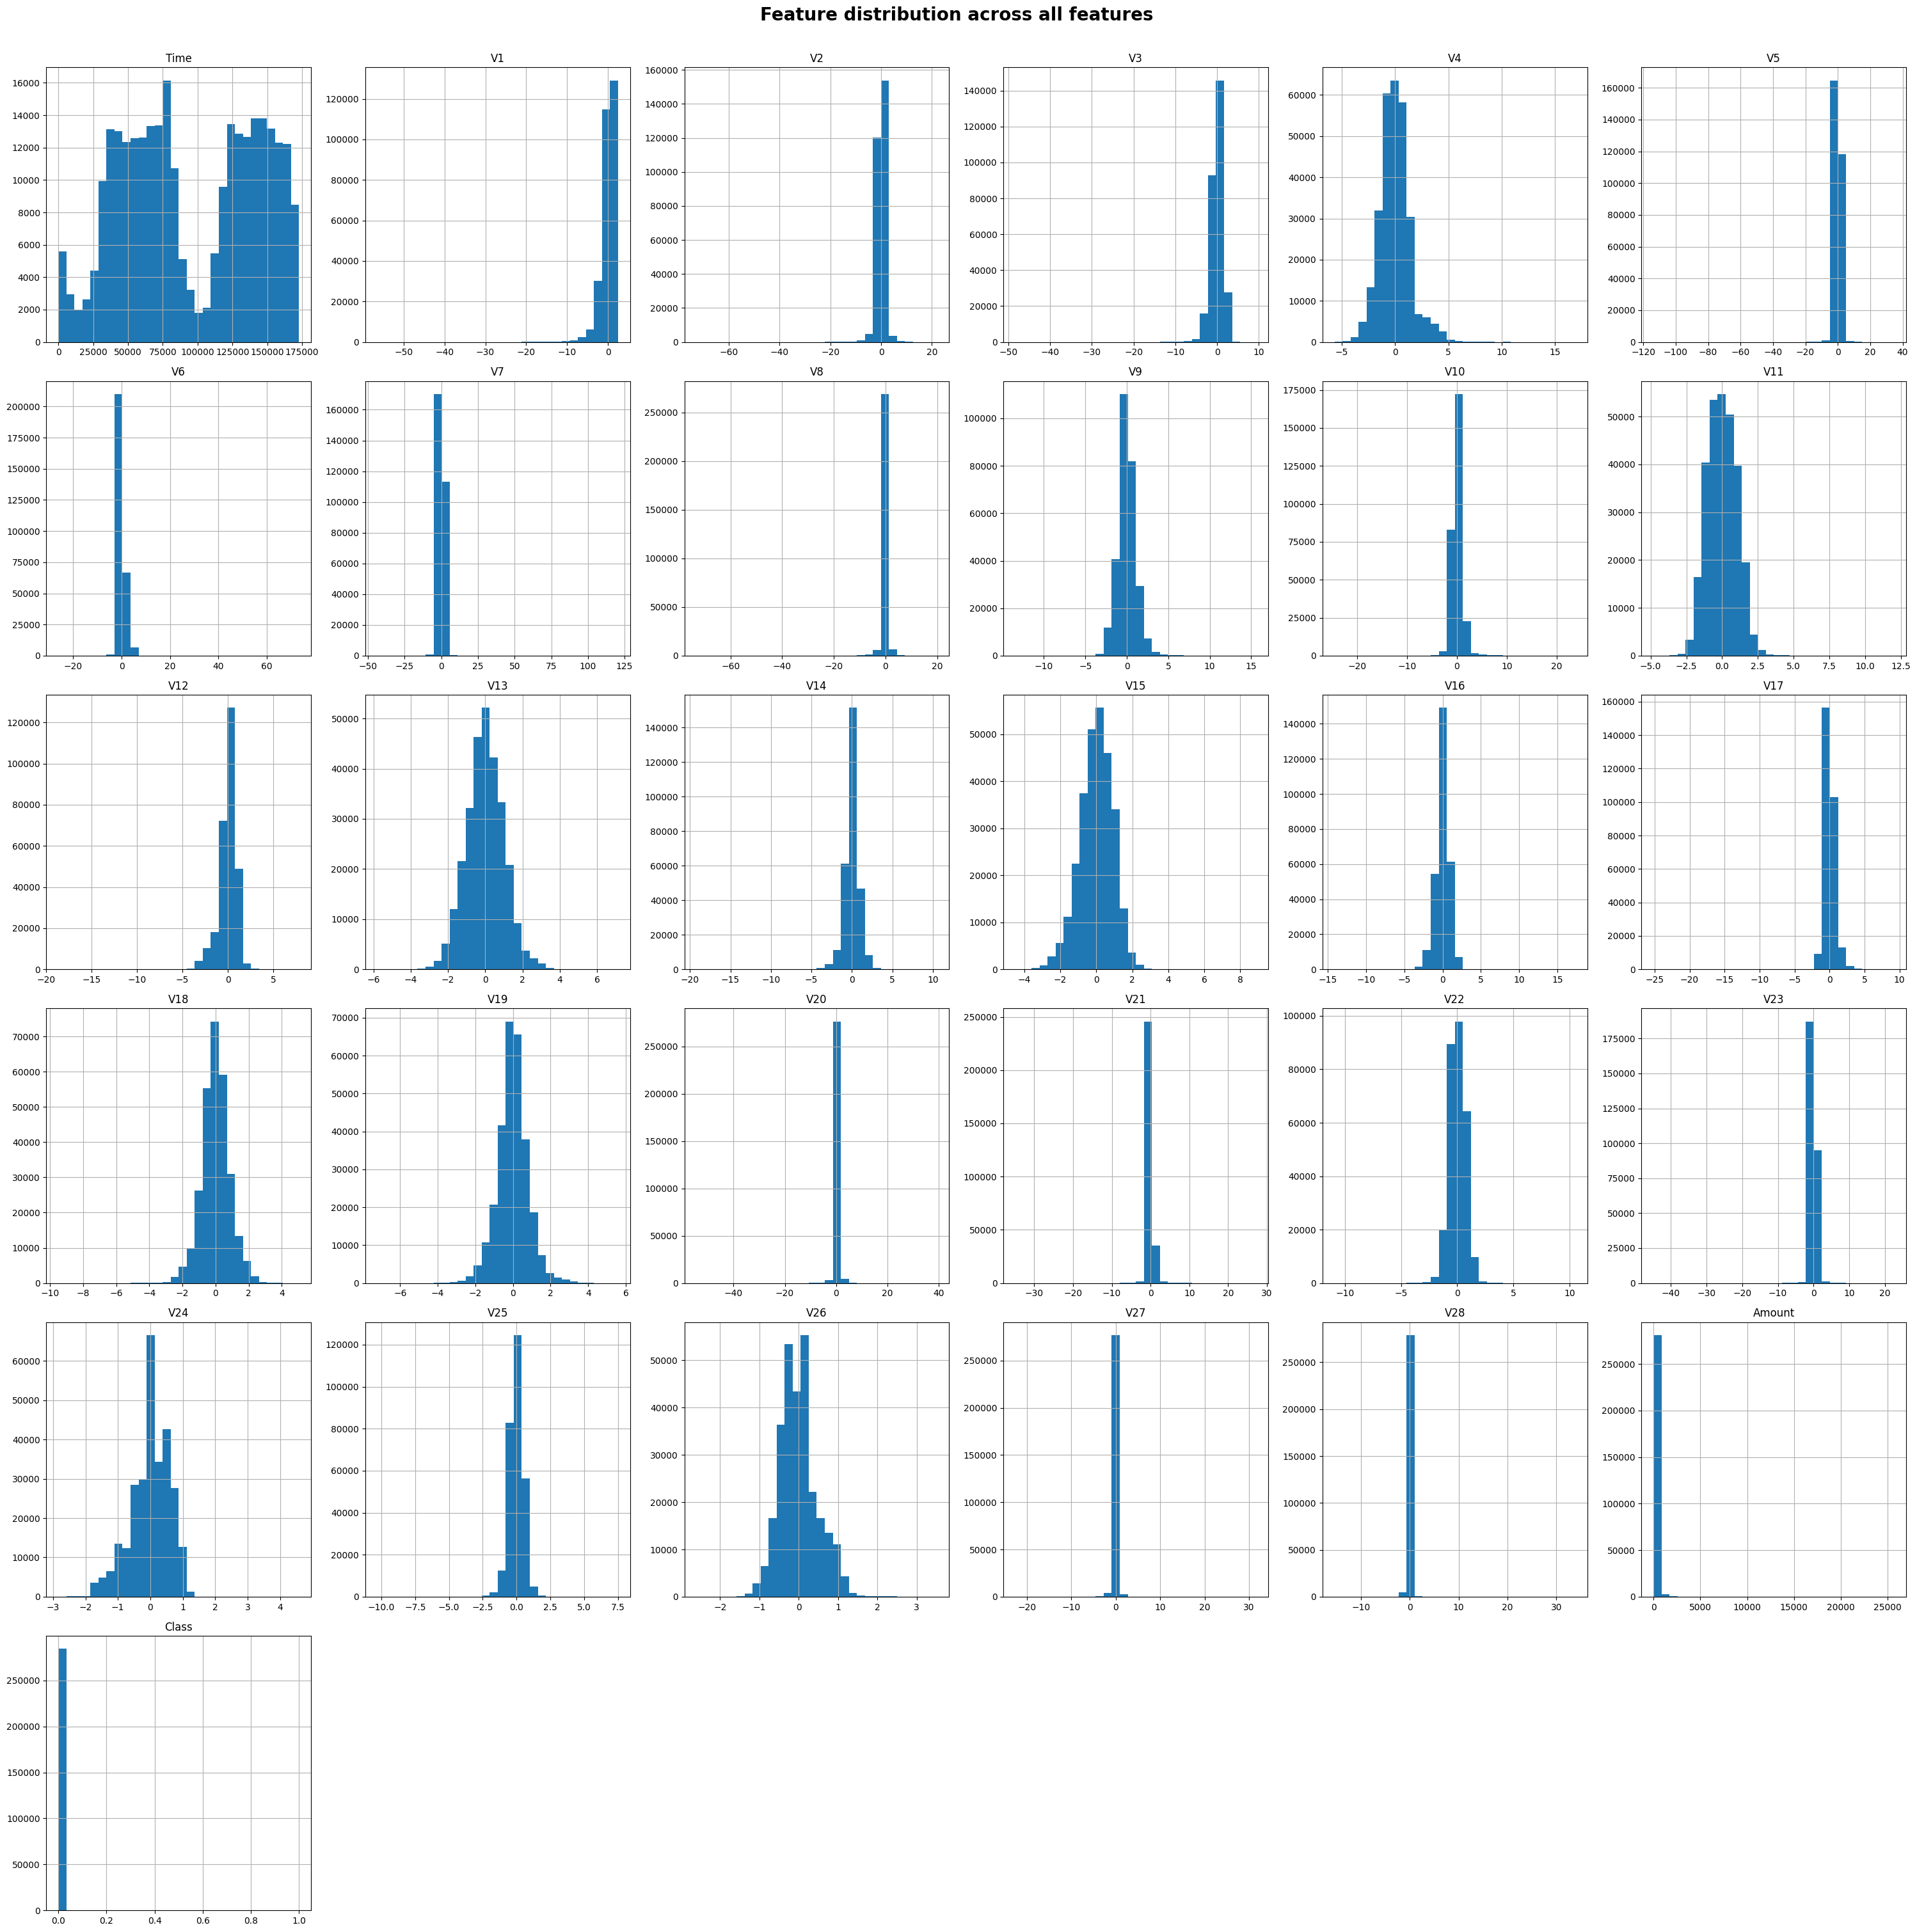

In [5]:
import matplotlib.pyplot as plt

df.hist(bins=30, figsize=(30, 30))
plt.suptitle('Feature distribution across all features', fontweight='bold', fontsize=20, y=1.005)
plt.savefig('plots/feature_distributions.png', dpi=200)
plt.tight_layout()
plt.show()

We can see that most of the histograms are almost normally distributed. However, `Amount` looks heavily imbalanced. Let's have a closer look with a log scale:

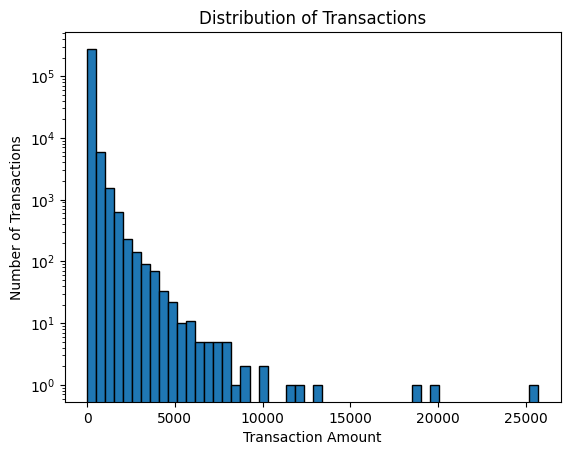

In [16]:
plt.hist(df['Amount'], bins=50, edgecolor='black')
plt.yscale("log")
plt.title("Distribution of Transactions")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.savefig('plots/amount_distribution_log_scale.png', dpi=200)
plt.show()

In [20]:
df[['Time', 'Amount', 'Class']].describe().round(2)

,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


We notice:
- The overwhelming majority of transactions are under €500 with one transaction reaching past €25,000. 
- This extreme right skew means that the mean (€88.35) is the result of heavily influence by the large numbers. 
- The median (€22), however, tells gives a different story:
    - mean ($88) is 4x the median ($22) -> Outlier distortion
    - max ($25,691) is ~1168x the median ($22) -> Extreme right skew

This directly influences our scaling strategy. StandardScaler would be distorted by these extreme outliers for `Amount`. Therefore, RobustScaler is the better choice since ituses median + IQR instead, making it immune to outlier influence.

### 1.3 Class Distribution

Let's see how many transactions are fraudulent (1) vs legitimate (0):

In [27]:
class_counts = df["Class"].value_counts().reset_index()
class_counts.columns = ["Class", "Count"]
class_counts["Percentage (%)"] = ((class_counts["Count"] / class_counts["Count"].sum()) * 100)

display(class_counts.style.hide(axis="index"))

Class,Count,Percentage (%)
0,284315,99.827251
1,492,0.172749


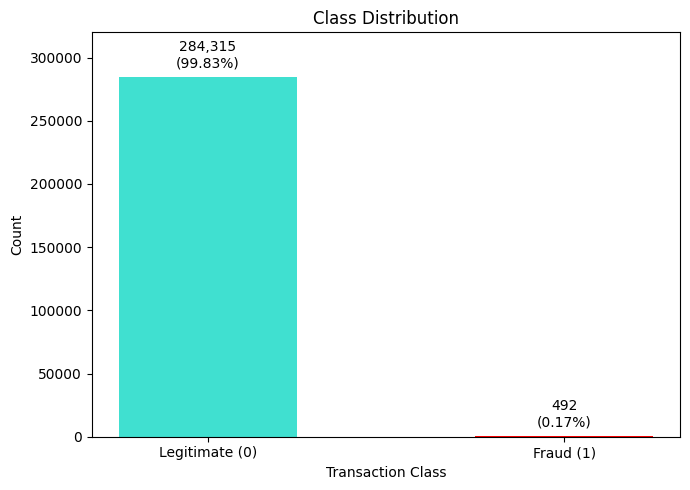

In [29]:
categories = ["Legitimate (0)", "Fraud (1)"]
values = [284315, 492]
percentages = [99.83, 0.17]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(categories, values, color=["turquoise", "red"], width=0.5)
labels = [f"{values[0]:,}\n({percentages[0]}%)", f"{values[1]:,}\n({percentages[1]}%)"]
ax.bar_label(bars, labels=labels, padding=5)
ax.set_title("Class Distribution")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Count")
ax.set_ylim(0, 320000)
plt.savefig('plots/class_distribution.png', dpi=200)
plt.tight_layout()
plt.show()

- The imbalance is extreme: a 578:1 ratio of legitimate to fraud. 
- Accuracy is useless here: The data is so imbalanced that a model can score high just by igonring the fraud class entirely. 
    - Recall fixes this by looking at at the fraud cases. 
- As a result:
    1. We will use SMOTE to synthetically create data to balance the training data so that the model can see enough fraud to learn from.

### 1.4 Transaction Amount Distribution

Do fraudulent transactions differ significantly by amount? Let's try to visualize the density:

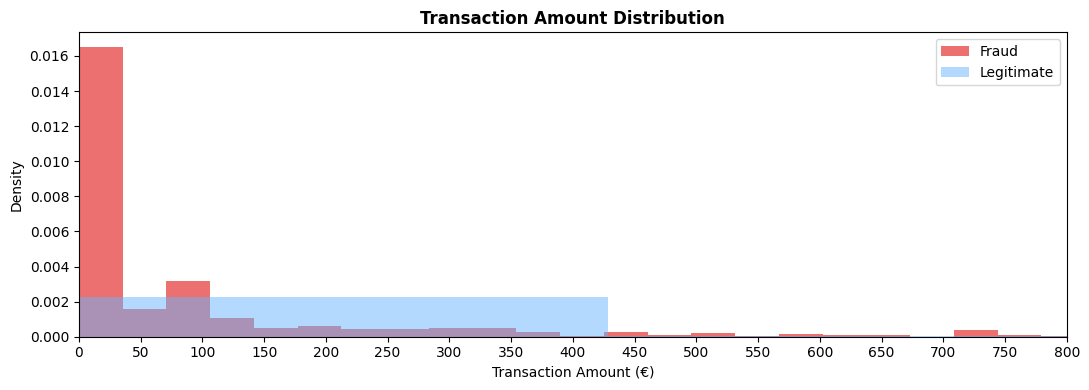

In [33]:
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(fraud, bins=60, alpha=0.8, color='#E84C4C', label='Fraud', density=True)
ax.hist(legit, bins=60, alpha=0.5, color="#69B4FF", label='Legitimate', density=True)
ax.set_xlim(0, 800)
ax.set_xticks(range(0, 801, 50))
ax.set_xlabel('Transaction Amount (€)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('plots/transaction_amount_distribution.png', dpi=150)
plt.show()

We notice a few things:
- We can see from the red spike from €0 – €50 that fraduluent transactions concentrate at low amounts. This is done on purpose to evade any red flags or signals.
- Legitimate transactions are more spread out.

### 1.5 Feature Correlations with Fraud

Using the correlation matrix, let's try to idenfity which features has the strongest correlation to fraud. Since V1–V28 are PCA components, we are identifying which principal components carry the most fraud signal. This will connect directly to our SHAP analysis later:

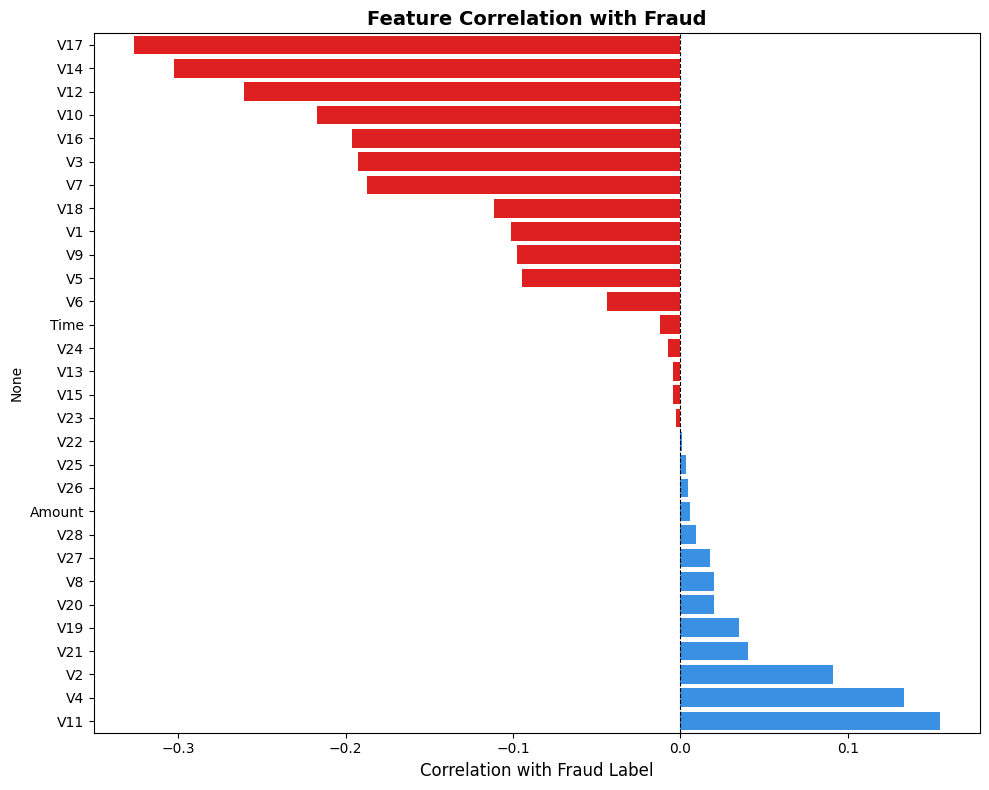

In [35]:
import seaborn as sns

correlations = df.corr()['Class'].drop('Class').sort_values()

colors = []
for c in correlations.values:
    if c < 0:
        colors.append('red')
    else:
        colors.append('#1E90FF')

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette=colors, hue=correlations.index, legend=False)

plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Correlation with Fraud Label', fontsize=12)
plt.title('Feature Correlation with Fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_correlations_with_fraud.png', dpi=150)
plt.show()

We notice that:
- V17 and V14 are the strongest fraud signals. Lower values of these components are strongly correlated with fraud
- Amount has almost no correlation with fraud. This doesn't mean Amount is useless; it's possible that the relationship is non-linear. We already showed in `1.4` that most fraud happens at low amounts, but this correlation isn't shown here due to non-linearity. This is why we use non-linear models like Random Forest, XGBoost, and MLP.

---

## 2. Preprocessing

A few things to note:

1. **Split first, then scale:** Fitting any scaler on data before splitting leaks test set statistics into training. As a result, the model looks better than it actually is. We fit only on training data, then apply to both.

2. **Stratify the split:** Since we have only 492 fraud cases, a random split could produce a test set with very few fraud examples. Therefore stratify in `train_test_split()` guarantees the same fraud ratio in both splits.

3. **RobustScaler over StandardScaler for Amount:** Amount has extreme outliers up to €25,691 against a median of €22. RobustScaler scales using median and IQR, so it remains immune to the outliers. StandardScaler's mean and standard deviation would both be skewed by them.

In [38]:
from sklearn.model_selection import train_test_split

X = df.loc[:, df.columns != "Class"]  # All features
y = df["Class"]                       # Target (0s and 1s)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples with {y_train.sum()} frauds")
print(f"Test set: {X_test.shape[0]:,} samples with {y_test.sum()} frauds")

Training set: 227,845 samples with 394 frauds
Test set: 56,962 samples with 98 frauds


**Train/Test Split Overview:**

```
Dataset: 284,807 total transactions
│
├── Training set: 227,845 transactions
│   ├── Legitimate: 227,451  (99.83%)
│   └── Fraud: 394            (0.17%)
│
└── Testing set: 56,962 transactions
    ├── Legitimate: 56,864   (99.83%)
    └── Fraud: 98             (0.17%)
```

### 2.1 Scaling Time and Amount

Since V1–V28 PCA-transformed, we only have to scale `Time` and `Amount`.

For `Amount`, we use **RobustScaler()** due to the outliers seen in the histograms above. For `Time`, we'll use RobustScaler as well for consistency, although `StandardScaler()` would work as well since time doesn't have an outlier problem:

In [50]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']]  = scaler.transform(X_test[['Time', 'Amount']])

Let's now see the median and standard deviation after scaling:

In [53]:
scaling_check = pd.DataFrame({
    'Median': [X_train['Time'].median(), X_train['Amount'].median()],
    'Std': [X_train['Time'].std(), X_train['Amount'].std()],
}, index=['Time', 'Amount']).round(2)

display(scaling_check)

,Median,Std
Time,0.0,0.56
Amount,0.0,3.53


We can see that the median is now 0. This is because `RobustScaler()` centers on the median, so the outliers no longer distort the scale.

Now we're ready for the algorithms.

---

## 3. Customer Segmentation: K-Means Clustering

For the first Machine Learning Algorithm, we'll use the K-Means Clustering. Before we even build fraud detectors, we ask ourselves: are there any noticable groups in this data? Through clustering, we can learn about spending patterns and frequent buyers. This would give us an idea what and where the "normal" amount lies in vs the fraud amounts.

K-Means works by minimizing the total squared distance from each point to its cluster centroid. There are 2 things to note:

- **K:** The number of clusters. We'll use the Elbow Method and Silhouette Score to determine the best K value.
- **Scaled features:** K-Means uses Euclidean distance, so unscaled features dominate the calculation. Our data is already scaled, so this is good.

### 3.1 Finding the best K value using the Elbow Method + Silhouette Score

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_numbers = [i for i in range(2, 11)]
inertia = []
silhouette_scores = []

for k in cluster_numbers:
    kmeans = KMeans(n_clusters=k, random_state=99)
    labels = kmeans.fit_predict(X_train)
    inertia.append(kmeans.inertia_)

    silhouette_average = silhouette_score(X_train, labels, sample_size=20000)
    silhouette_scores.append(silhouette_average)

best_k = cluster_numbers[silhouette_scores.index(max(silhouette_scores))]
print(f"Best K from the silhouette score: {best_k}")

Best K by silhouette score: 2


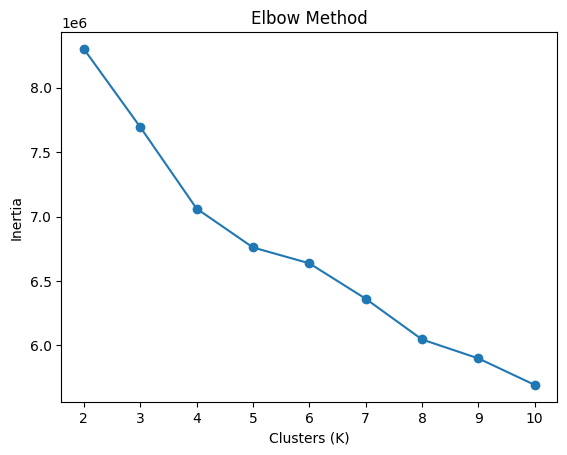

In [62]:
plt.plot(cluster_numbers, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters (K)")
plt.ylabel("Inertia")
plt.savefig('plots/elbow_method.png', dpi=200)
plt.show()

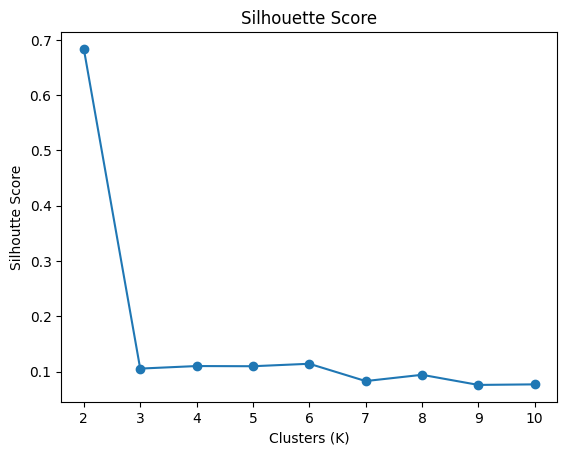

In [61]:
plt.plot(cluster_numbers, silhouette_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Clusters (K)")
plt.ylabel("Silhoutte Score")
plt.savefig('plots/silhouette_score.png', dpi=200)
plt.show()

We can see that the silhouette score has a peak at K=2 and then drops
drops. The elbow curve shows no clear bend. When the two methods differ, silhouette score is the more reliable indicator, so we proceed with K=2.

It also makes sense since in this context, we're working with typical behavior vs atypical behavior.

### 3.2 Fitting K-Means Model

We picked K=2 as the best amount of clusters due to a high silhouette score, so cluster separation is strongest at this K. Let's fit the model into the training data:

In [71]:
kmeans = KMeans(n_clusters=2, random_state=99)
train_clusters = kmeans.fit_predict(X_train)
test_clusters = kmeans.predict(X_test)

print(f"From the training set of {len(train_clusters)} transactions:\n")
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} transactions ({count/len(train_clusters)*100:.2f}%)")

From the training set of 227845 transactions:

Cluster 0: 4328 transactions (1.90%)
Cluster 1: 223517 transactions (98.10%)


We can see that K-Means identified two clusters without ever being told which transactions were legitimate or fraudulent. This is fully unsupervised.

- Cluster 0 contains 1.9% of transactions, which mirrors the 0.17% fraud rate in the dataset. This small cluster captured irregular activity and the model was able to naturally isolate this minority.

- Similarly, cluster 1 contains 98.1% of transactions, mirring the 99.83% of legitimate transactions.

This makes sense, especially with our choice of K=2 that we are separating typical and atypical behavior. We'll confirm this in the cluster profile and PCA visualization next.